# Stock Market Analysis - India vs US

# API Setup & Data Collection

Installing libraries


In [1]:
import requests
import pandas as pd
import os
from datetime import datetime
import time

print("libraries installed")

libraries installed


API Configuration

In [2]:
from google.colab import userdata
API_KEY = userdata.get('ALPHA_VANTAGE_KEY')

TICKERS = {
    "RELIANCE" : "RELIANCE.BSE", #BSE (bombay stock exchange)
    "TCS"      : "TCS.BSE",
    "INFY"     : "INFY.BSE",
    "HDFCBANK" : "HDFCBANK.BSE",
    "WIPRO"    : "WIPRO.BSE",
    "ICICIBANK" : "ICICIBANK.BSE",
    "AAPL"     : "AAPL",
    "MSFT"     : "MSFT",
}
BASE_URL = "https://www.alphavantage.co/query"
print(f"Tracking {len(TICKERS)} stocks")

Tracking 8 stocks


Fetch Function

In [3]:
def fetch_stock_data(symbol, api_key):
  params = {
      "function" : "TIME_SERIES_DAILY",
      "symbol"  : symbol,
      "outputsize" : "compact",
      "apikey"     : api_key
  }
  response = requests.get(BASE_URL, params=params)
  data = response.json()

  if "Time Series (Daily)" not in data:
    print(f"Unexpected response : {list(data.keys())}")
    return None

  time_series = data["Time Series (Daily)"]

  rows =[]

  for date, values in time_series.items():
    rows.append({
        "date" : date,
        "open" : float(values["1. open"]),
        "high" : float(values["2. high"]),
        "low"  : float(values["3. low"]),
        "close" : float(values["4. close"]),
        "volume" : int(values["5. volume"])
    })

  df = pd.DataFrame(rows)
  df["date"] = pd.to_datetime(df["date"])
  df = df.sort_values("date").reset_index(drop = True)

  return df

In [4]:
df = fetch_stock_data("TCS.BSE",API_KEY)
print(df.head())
print(df.dtypes)

        date       open       high        low      close  volume
0 2026-01-23  3152.1001  3193.7500  3152.0000  3160.8501   95171
1 2026-01-26  3160.8501  3160.8501  3160.8501  3160.8501       0
2 2026-01-27  3161.2000  3176.5000  3131.0000  3158.3999  164571
3 2026-01-28  3160.1001  3205.0000  3160.1001  3199.8501  144008
4 2026-01-29  3199.8501  3200.0000  3126.5500  3146.1001  194322
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object


In [5]:
all_data = {}

for key,symbol in TICKERS.items():
  all_data[key] = fetch_stock_data(symbol, API_KEY)
  print(f"Fetched {key}")
  time.sleep(20)

Fetched RELIANCE
Fetched TCS
Fetched INFY
Fetched HDFCBANK
Fetched WIPRO
Fetched ICICIBANK
Fetched AAPL
Fetched MSFT


saving as csv file

In [6]:
for key, df in all_data.items():
  df["ticker"] = key

combined_df = pd.concat(all_data.values(), ignore_index = True)
print(combined_df.shape)
print(combined_df.head())
print(combined_df["ticker"].value_counts())

(800, 7)
        date     open     high      low    close   volume    ticker
0 2026-01-20  1414.95  1415.75  1390.10  1393.40   261965  RELIANCE
1 2026-01-21  1388.05  1412.70  1373.00  1403.90   416973  RELIANCE
2 2026-01-22  1410.20  1419.75  1395.10  1401.80   712993  RELIANCE
3 2026-01-23  1403.95  1407.15  1381.15  1385.95   203908  RELIANCE
4 2026-01-27  1385.85  1391.90  1368.50  1381.05  3536849  RELIANCE
ticker
RELIANCE     100
TCS          100
INFY         100
HDFCBANK     100
WIPRO        100
ICICIBANK    100
AAPL         100
MSFT         100
Name: count, dtype: int64


In [7]:
os.makedirs("data", exist_ok = True)
combined_df.to_csv("data/all_stocks.csv", index = False)
print("Saved")

Saved


In [8]:
print(os.listdir("data"))

['all_stocks.csv']


- 8 stocks fetched (6 Indian, 2 US)
- 800 rows × 7 columns
- Saved to data/all_stocks.csv
- Date range: Jan 2026 to Jun 2026

# Exploratory Data Analysis (EDA)

Loading the combined csv file

In [ ]:
from google.colab import files
files.download("data/all_stocks.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from google.colab import files
uploaded = files.upload()

Saving all_stocks.csv to all_stocks.csv


In [10]:
df = pd.read_csv("data/all_stocks.csv")
df["date"] = pd.to_datetime(df["date"])
print(df.shape)
print(df.dtypes)

(800, 7)
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
ticker            object
dtype: object


In [11]:
print(df.isnull().sum())

date      0
open      0
high      0
low       0
close     0
volume    0
ticker    0
dtype: int64


In [12]:
print(df.describe())

                      date         open         high          low  \
count                  800   800.000000   800.000000   800.000000   
mean   2026-04-06 18:14:24  1027.397686  1037.741293  1015.120755   
min    2026-01-20 00:00:00   177.950000   178.200000   175.800000   
25%    2026-02-27 00:00:00   349.965000   351.187500   344.622500   
50%    2026-04-08 00:00:00  1037.900000  1053.225000  1018.900000   
75%    2026-05-14 00:00:00  1363.075000  1378.000000  1350.700000   
max    2026-06-18 00:00:00  3320.899900  3336.700000  3185.550000   
std                    NaN   735.067904   741.801489   724.849354   

             close        volume  
count   800.000000  8.000000e+02  
mean   1025.304888  1.145315e+07  
min     177.400000  0.000000e+00  
25%     346.377500  4.295108e+05  
50%    1024.525000  1.069590e+06  
75%    1364.650000  9.877395e+06  
max    3223.700000  1.288553e+08  
std     731.760393  1.964276e+07  


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    800 non-null    datetime64[ns]
 1   open    800 non-null    float64       
 2   high    800 non-null    float64       
 3   low     800 non-null    float64       
 4   close   800 non-null    float64       
 5   volume  800 non-null    int64         
 6   ticker  800 non-null    object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 43.9+ KB
None


In [14]:
df.groupby("ticker")['close'].mean().sort_values(ascending = False)

,close
ticker,
TCS,2520.189003
RELIANCE,1376.310500
ICICIBANK,1311.149500
INFY,1286.553500
HDFCBANK,824.363000
MSFT,405.612500
AAPL,274.746100
WIPRO,203.515000


In [15]:
# getting the first & last close price for each stock
returns = df.groupby("ticker")["close"].agg(["first","last"])

# calculating return percentage
returns["return_%"] = ((returns["last"] - returns["first"])/returns["first"] * 100)

#sorting by best performer
returns = returns.sort_values("return_%", ascending = False)
print(returns)

               first     last   return_%
ticker                                  
AAPL        258.2700   298.01  15.386998
ICICIBANK  1343.3500  1342.55  -0.059553
RELIANCE   1393.4000  1327.75  -4.711497
HDFCBANK    931.1500   798.55 -14.240455
MSFT        480.5800   379.40 -21.053727
WIPRO       238.3500   182.80 -23.306063
TCS        3160.8501  2204.30 -30.262432
INFY       1670.6000  1127.25 -32.524243


In [16]:
df["daily_range"] = df["high"] - df["low"]
volatility = df.groupby("ticker")["daily_range"].mean().sort_values(ascending = False)
print(volatility)

ticker
TCS          59.599988
INFY         31.766500
RELIANCE     28.208500
ICICIBANK    24.222000
HDFCBANK     16.931500
MSFT          9.610651
AAPL          5.951660
WIPRO         4.673500
Name: daily_range, dtype: float64


Visualisation

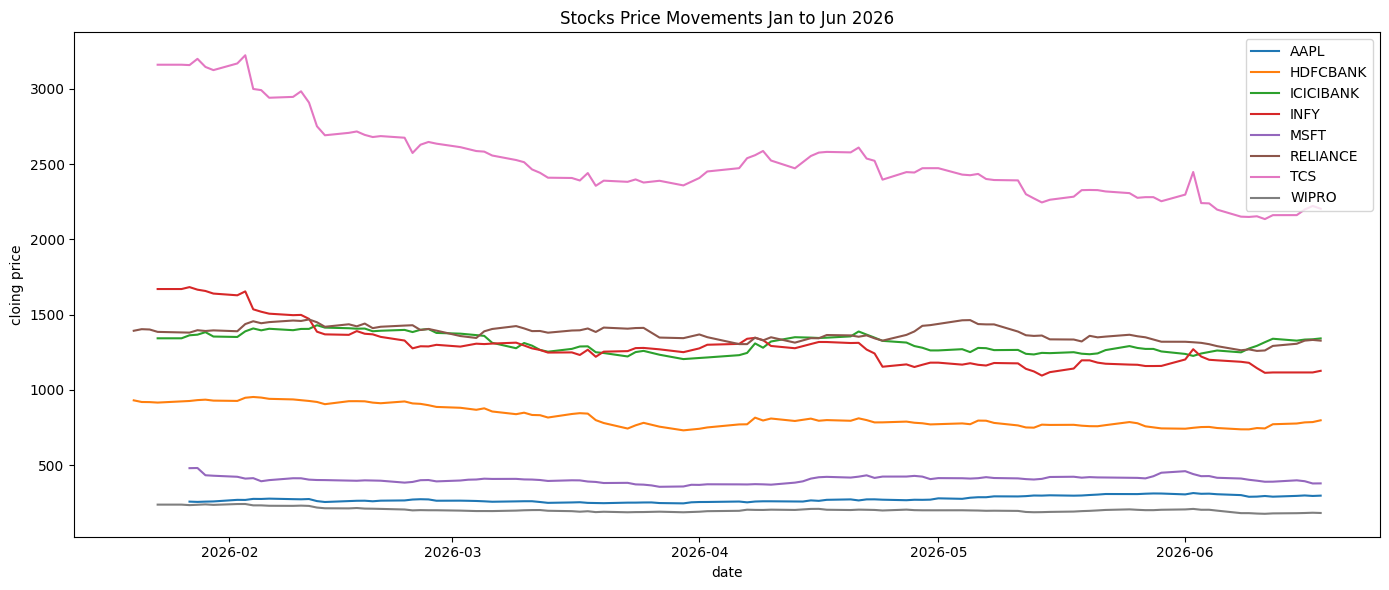

In [17]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize = (14,6))

for ticker,group in df.groupby("ticker"):
    ax.plot(group["date"],group["close"], label = ticker)

ax.set_title("Stocks Price Movements Jan to Jun 2026")
ax.set_xlabel("date")
ax.set_ylabel("cloing price")
ax.legend()
plt.tight_layout()
plt.show()

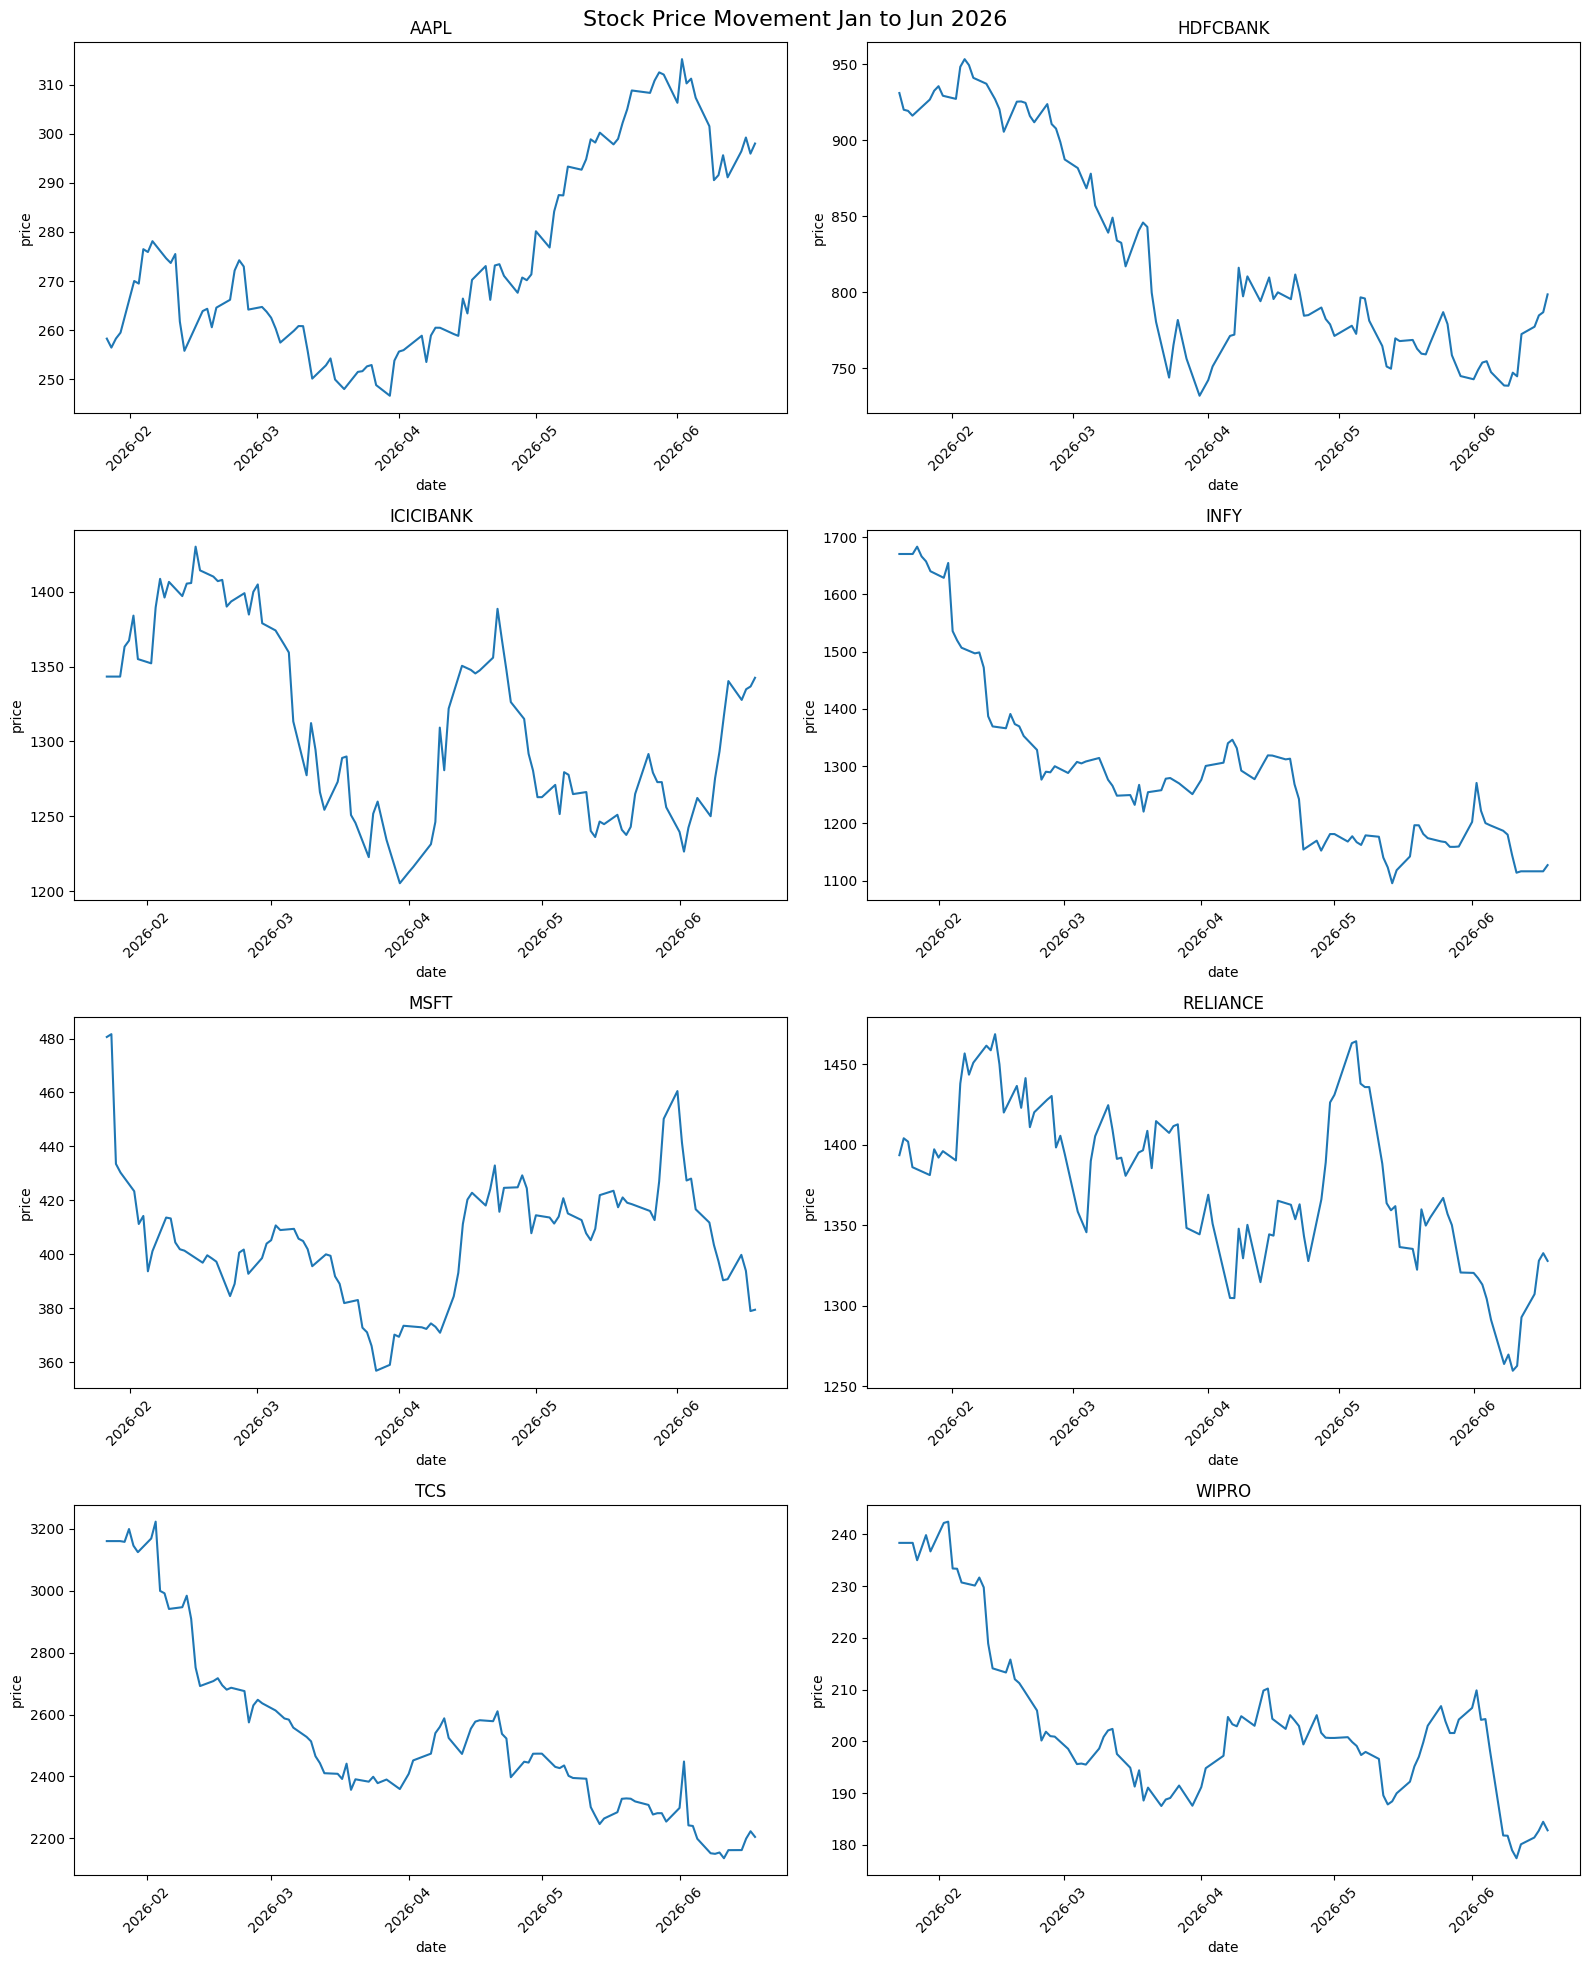

In [18]:
fig, axes = plt.subplots(4,2, figsize = (16,20))
axes = axes.flatten()

for i, (ticker, group) in enumerate(df.groupby("ticker")):
    axes[i].plot(group["date"],group["close"])
    axes[i].set_title(ticker)
    axes[i].set_xlabel("date")
    axes[i].set_ylabel("price")
    axes[i].tick_params(axis="x", rotation=45)

plt.suptitle("Stock Price Movement Jan to Jun 2026", fontsize=16)
plt.tight_layout()
plt.show()

In [19]:
# calculating 20 day moving average for each stock

df["MA20"] = df.groupby("ticker")["close"].transform(
    lambda x: x.rolling(window=20).mean()
)
print(df[["date","ticker","close","MA20"]].head(25))

         date    ticker    close       MA20
0  2026-01-20  RELIANCE  1393.40        NaN
1  2026-01-21  RELIANCE  1403.90        NaN
2  2026-01-22  RELIANCE  1401.80        NaN
3  2026-01-23  RELIANCE  1385.95        NaN
4  2026-01-27  RELIANCE  1381.05        NaN
5  2026-01-28  RELIANCE  1397.05        NaN
6  2026-01-29  RELIANCE  1391.90        NaN
7  2026-01-30  RELIANCE  1395.90        NaN
8  2026-02-02  RELIANCE  1390.15        NaN
9  2026-02-03  RELIANCE  1437.85        NaN
10 2026-02-04  RELIANCE  1456.60        NaN
11 2026-02-05  RELIANCE  1443.40        NaN
12 2026-02-06  RELIANCE  1450.85        NaN
13 2026-02-09  RELIANCE  1461.40        NaN
14 2026-02-10  RELIANCE  1458.55        NaN
15 2026-02-11  RELIANCE  1468.55        NaN
16 2026-02-12  RELIANCE  1449.85        NaN
17 2026-02-13  RELIANCE  1419.90        NaN
18 2026-02-16  RELIANCE  1436.40        NaN
19 2026-02-17  RELIANCE  1422.80  1422.3625
20 2026-02-18  RELIANCE  1441.25  1424.7550
21 2026-02-19  RELIANCE  1410.80

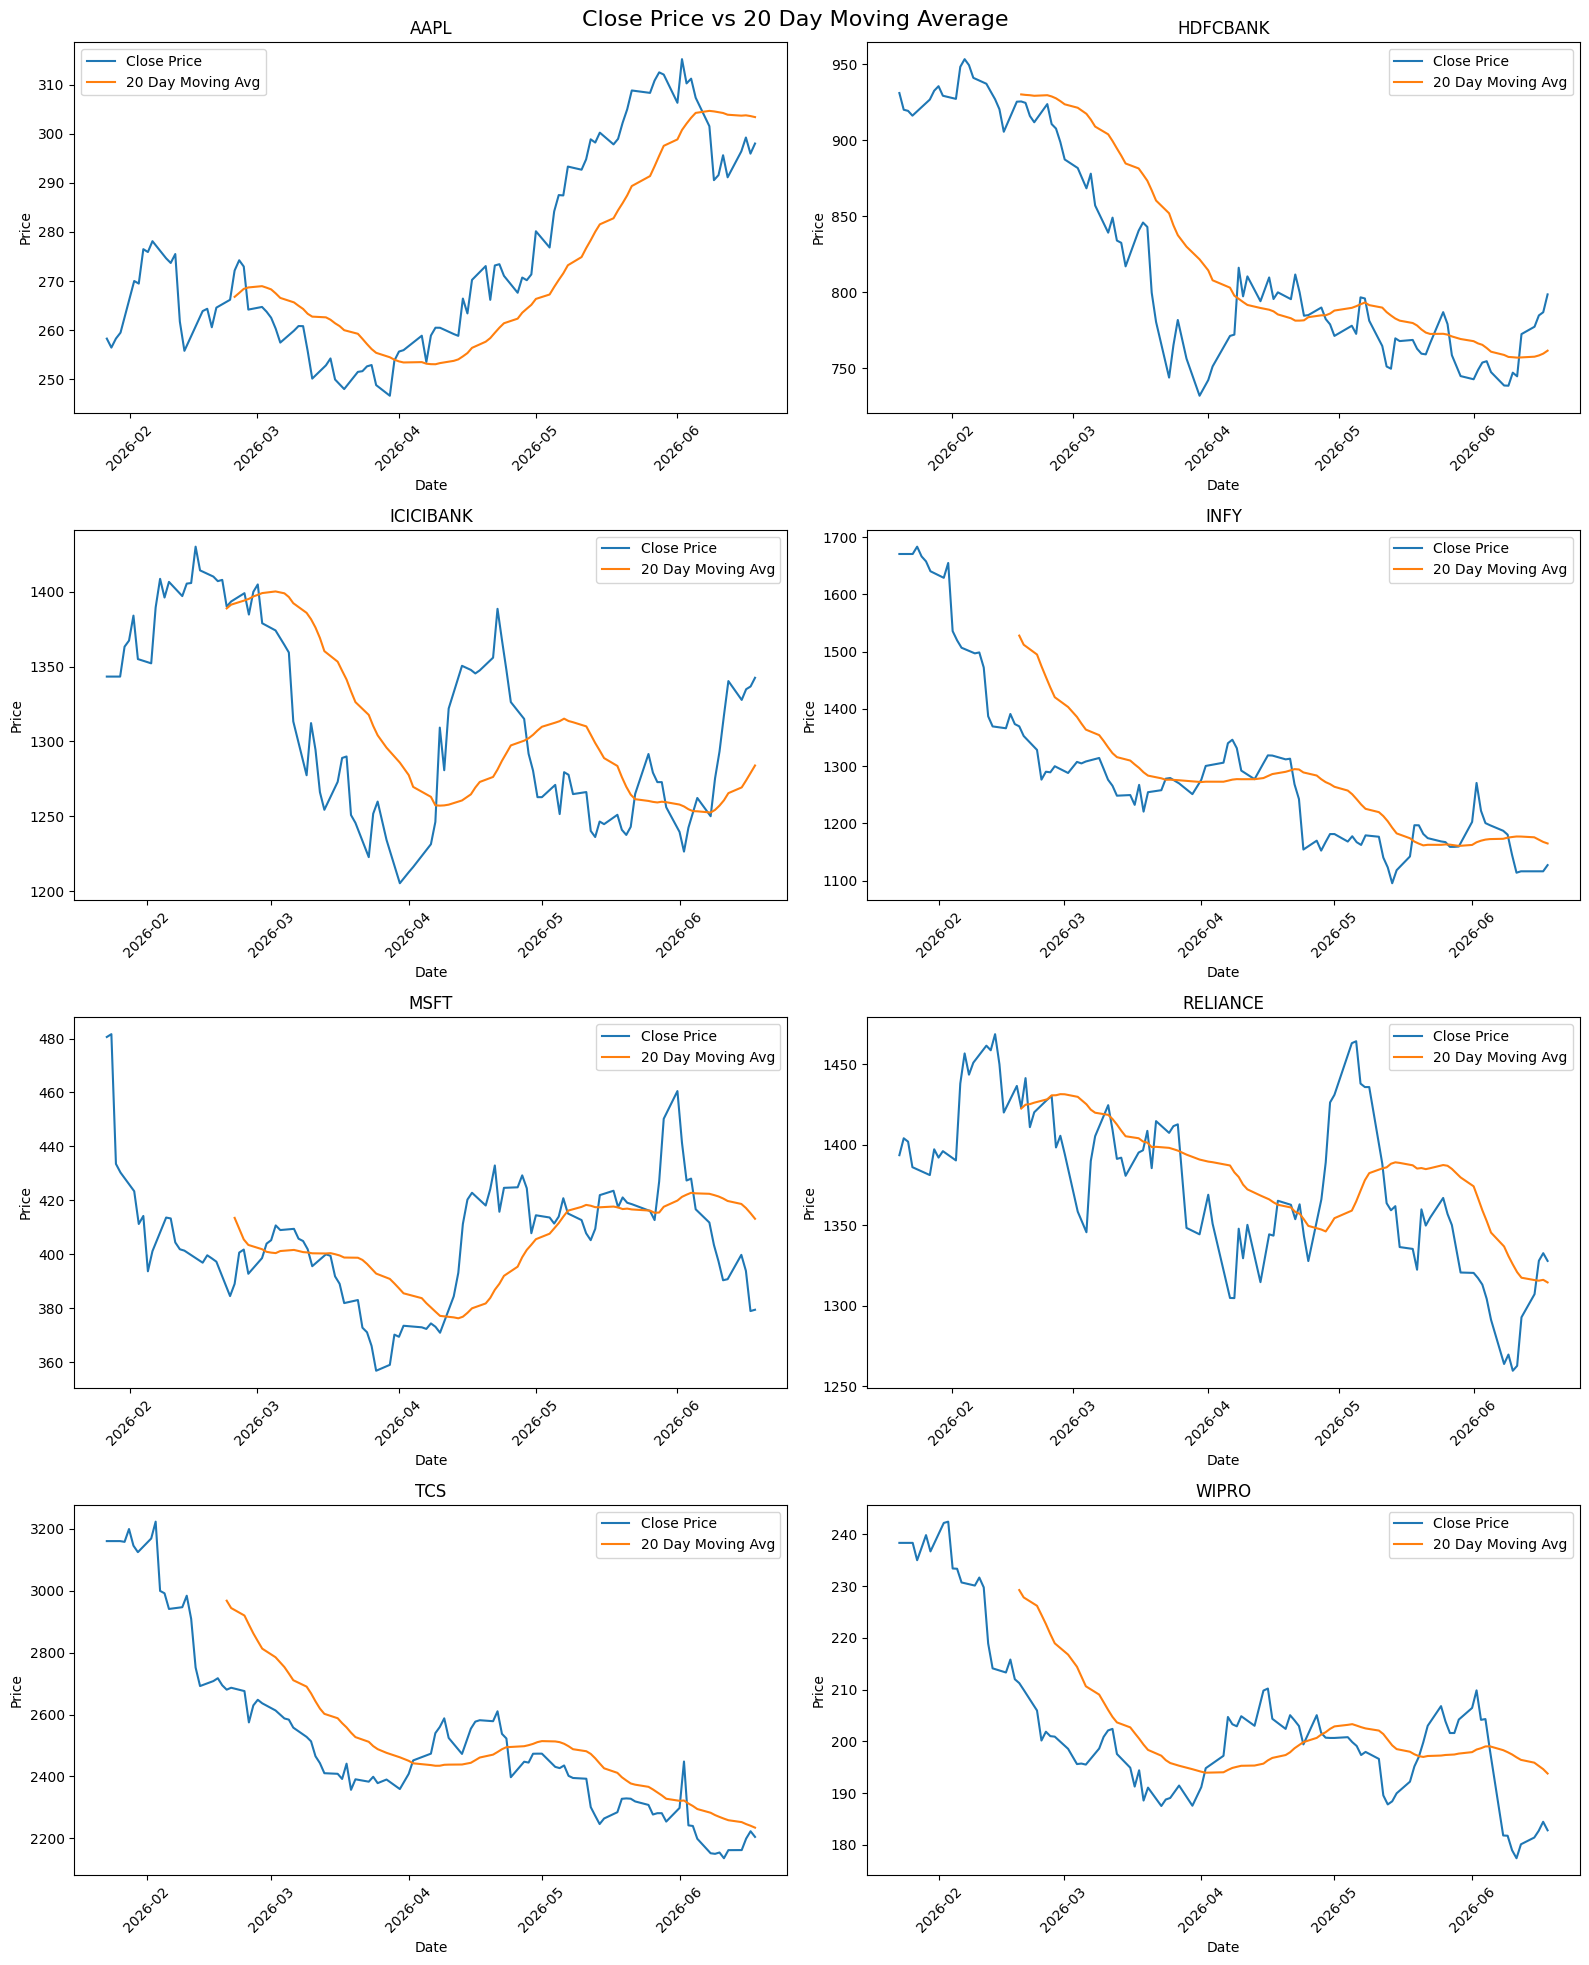

In [20]:
fig, axes = plt.subplots(4,2,figsize=(16,20))
axes = axes.flatten()

for i, (ticker,group) in enumerate(df.groupby("ticker")):
  axes[i].plot(group["date"],group["close"],label="Close Price")
  axes[i].plot(group["date"],group["MA20"],label="20 Day Moving Avg")
  axes[i].set_title(ticker)
  axes[i].set_xlabel("Date")
  axes[i].set_ylabel("Price")
  axes[i].legend()
  axes[i].tick_params(axis="x",rotation=45)

plt.suptitle("Close Price vs 20 Day Moving Average",fontsize=16)
plt.tight_layout()
plt.show()


# INSIGHTS
1. AAPL was the only stock with a positive return (+19.3%)
   over Jan to Jun 2026

2. Indian IT stocks underperformed significantly TCS (-30.4%)
   and INFY (-31.5%) were the worst performers

3. TCS and INFY showed highest volatility despite falling prices
   large daily price swings throughout the period

4. 20 day moving average confirms Indian stocks in consistent
   downtrend, AAPL in consistent uptrend